# comparación analítica con dayem

**Fecha:** 2026-05-07


# 1. Establecer el cambio de coordenadas en relatipy

In [1]:
!pip install -q -e ../../relatipy

In [2]:
import relatipy as rp
import relatipy.numeric as rn
from relatipy.visualization._3D.plot_black_hole import PlotKerr
from relatipy.numeric.metrics import Kerr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({"savefig.dpi": 200, "savefig.bbox": "tight", "figure.dpi": 120})

FIGURES_DIR = "../figures/007-comparacion_analitica_con_dayem"

In [4]:
kerr = Kerr(mass=1, a=0.5)

In [5]:
R_s = kerr.R_s
ics = rn.coordinates.ApparentOrbitalElements(
    a=10*R_s,
    zeta=45,
    eta=30
    )

P = ics._get_period()

In [6]:
import numpy as np
path = kerr.geodesic.get_path(
    ics, np.linspace(0, P,1000)
)


In [7]:
plot = PlotKerr(kerr)
plot.add_path(path)
fig_3d = plot.plot()
fig_3d.write_html(f"{FIGURES_DIR}/orbit_coordinate_validation.html")
fig_3d

In [8]:
path.convert_to("Cartesian").convert_to("ApparentOrbitalElements",mass=1, zeta=45, eta=0)

# 2. Hacer el experimento con S2

In [9]:
import numpy as np
from numpy import cos, sin, tan
cot = lambda x: 1/tan(x)
import relatipy.numeric.constants as rconst

In [10]:
class Dayem2025:
    def __init__(self, ics, a) -> None:
        self.a_sma = ics.a
        self.e = ics.e
        self.p = self.a_sma * (1 - self.e**2)   # BUG1 fix: semilatus rectum, no pericenter
        self.i = np.deg2rad(ics.inc)
        # BUG fix: epsilon en unidades geometrizadas (M_BH = 1 r_g),
        # antes mezclaba G,c SI con mass=1 global (coincidencia numérica).
        self.epsilon = 1.0 / self.p
        self.mass = ics.mass
        self.chi = a

        self.theta, self.beta = np.deg2rad(self.get_theta_beta_from_ApparentOrbitalElements(ics))

    # theta & beta from zeta y eta
    # Dayem (2025) Ec. B.5 / help/angles_deduction.md
    def get_theta_beta_from_ApparentOrbitalElements(self, ics):
        zeta = np.deg2rad(ics.zeta)
        eta  = np.deg2rad(ics.eta)

        i     = np.deg2rad(ics.inc)
        Omega = np.deg2rad(ics.Omega)
        omega = np.deg2rad(ics.omega)

        dOmega = Omega - eta

        cos_theta = np.cos(zeta)*np.cos(i) + np.sin(zeta)*np.sin(i)*np.sin(dOmega)
        st_cos_b  = np.sin(zeta)*np.cos(dOmega)
        st_sin_b  = np.cos(zeta)*np.sin(i) - np.sin(zeta)*np.cos(i)*np.sin(dOmega)

        theta = np.arccos(np.clip(cos_theta, -1.0, 1.0))
        beta  = np.arctan2(st_sin_b, st_cos_b) % (2*np.pi)

        theta = np.rad2deg(theta)
        beta  = np.rad2deg(beta)

        return np.array([theta, beta])

    ### Omega precession contributions
    def get_Delta_omega_Q(self):
        # Dayem (2025) Ec. 19
        return (
            -(3*np.pi/2) * self.epsilon**2 *
                (1 - 3*cos(self.theta)**2 - 2*cot(self.i)*cos(self.theta)*sin(self.theta)*sin(self.beta)
                ) * self.chi**2
        )

    def get_Delta_omega_LT(self):
        # Dayem (2025) Ec. 18
        return (
            -4*np.pi * self.epsilon**(3/2) * (
                2*cos(self.theta) + cot(self.i)*sin(self.theta)*sin(self.beta)
            ) * self.chi
        )

    def get_Delta_omega_Sch(self):
        # Dayem (2025) Ec. 26: 1PN + 2PN correction
        return 6*np.pi*self.epsilon - (3*np.pi/2)*self.epsilon**2*(10 - self.e**2)

    def get_Delta_omega(self):
        Delta_omega = self.get_Delta_omega_Sch()
        if not (np.isclose(self.i, 0) or np.isclose(self.i, np.pi)):  # BUG3 fix: isclose + precedencia
            Delta_omega += self.get_Delta_omega_LT()
            Delta_omega += self.get_Delta_omega_Q()
        return Delta_omega

    ### i precession contributions
    def get_Delta_i_Sch(self):
        return 0

    def get_Delta_i_LT(self):
        # Dayem (2025) Ec. 21
        return (
            4*np.pi * self.epsilon**(3/2) * sin(self.theta)*cos(self.beta) * self.chi
        )

    def get_Delta_i_Q(self):
        # Dayem (2025) Ec. 22
        return (
            -3*np.pi * self.epsilon**2 * cos(self.theta)*sin(self.theta)*cos(self.beta) * self.chi**2
        )

    def get_Delta_i(self):
        return self.get_Delta_i_Sch() + self.get_Delta_i_LT() + self.get_Delta_i_Q()

    ### sin(i) * Delta_Omega precession contributions
    def get_Delta_sin_i_Delta_Omega_Sch(self):
        return 0

    def get_Delta_sin_i_Delta_Omega_LT(self):
        # Dayem (2025) Ec. 24
        return (
            4*np.pi * self.epsilon**(3/2) * sin(self.theta)*sin(self.beta) * self.chi
        )

    def get_Delta_sin_i_Delta_Omega_Q(self):
        # Dayem (2025) Ec. 25: sin(ι) ΔΩ_Q = −3π ε² cos(θ) sin(θ) sin(β) χ²
        return (
            -3*np.pi * self.epsilon**2 * cos(self.theta) * sin(self.theta) * sin(self.beta) * self.chi**2
        )

    def get_Delta_sin_i_Delta_Omega(self):
        return (
            self.get_Delta_sin_i_Delta_Omega_Sch()
            + self.get_Delta_sin_i_Delta_Omega_LT()
            + self.get_Delta_sin_i_Delta_Omega_Q()
        )


In [11]:
a = 0.9
mass = 1

In [12]:
# S2 — GRAVITY Collaboration 2020, A&A 636, L5, Tab. 1
# Conversión: mas → AU → r_g

a_mas     = 125.058      # mas
dist_pc   = 8277.0       # pc
M_SgrA    = 4.154e6      # M_sun

# 1 arcsec a 1 pc = 1 AU  →  a[AU] = a[arcsec] * d[pc]
a_AU = (a_mas / 1e3) * dist_pc   # mas → arcsec → AU

G_SI  = 6.674e-11        # m^3 kg^-1 s^-2
c_SI  = 2.998e8          # m/s
Msun  = 1.989e30         # kg
AU_m  = 1.496e11         # m/AU

r_g_m  = G_SI * M_SgrA * Msun / c_SI**2
r_g_AU = r_g_m / AU_m
a_rg   = a_AU / r_g_AU

print(f"a_S2 = {a_AU:.1f} AU = {a_rg:.0f} r_g")

ics_s2 = rn.coordinates.ApparentOrbitalElements(
    a     = a_rg,
    e     = 0.884649,
    inc   = 134.567,
    Omega = 228.171,
    omega = 66.263,
    zeta  = 0.0,
    eta   = 0.0,
    mass  = M_SgrA,
)
P = ics_s2._get_period()

a_S2 = 1035.1 AU = 25240 r_g


In [13]:
a_rg

25240.142762436135

In [14]:
dayem_s2 = Dayem2025(ics_s2, a=a)

print(f"Δω_tot  = {np.rad2deg(dayem_s2.get_Delta_omega()):.6f} deg/orb")
print(f"Δi_tot  = {np.rad2deg(dayem_s2.get_Delta_i()):.6f} deg/orb")
print(f"Δ(sin(i) ΔΩ)_tot  = {np.rad2deg(dayem_s2.get_Delta_sin_i_Delta_Omega()):.6f} deg/orb")

Δω_tot  = 0.200109 deg/orb
Δi_tot  = 0.000000 deg/orb
Δ(sin(i) ΔΩ)_tot  = 0.001143 deg/orb


In [15]:
import pandas as pd
from scipy.signal import find_peaks

kerr = Kerr(mass=1, a=a)

N_pts = 50000
times = np.linspace(0, 1.2 * P, N_pts)
path = kerr.geodesic.get_path(ics_s2, times, integrator="Radau2", adaptative=False)

xs_cart = path.convert_to("Cartesian").xs
r_t = np.sqrt(xs_cart[1]**2 + xs_cart[2]**2 + xs_cart[3]**2)
peri_idx, _ = find_peaks(-r_t, distance=N_pts // 4)
if r_t[0] < r_t[1] and (len(peri_idx) == 0 or peri_idx[0] > 50):
    peri_idx = np.concatenate([[0], peri_idx])

assert len(peri_idx) >= 2, f"Faltan pericentros: {len(peri_idx)}"
i0, i1 = peri_idx[0], peri_idx[1]

omega_unw = np.unwrap(np.deg2rad(path.omega))
inc_unw   = np.unwrap(np.deg2rad(path.inc))
Omega_unw = np.unwrap(np.deg2rad(path.Omega))

om_a  = np.rad2deg(dayem_s2.get_Delta_omega())
in_a  = np.rad2deg(dayem_s2.get_Delta_i())
sin_a = np.rad2deg(dayem_s2.get_Delta_sin_i_Delta_Omega())

om_n  = np.rad2deg(omega_unw[i1] - omega_unw[i0])
in_n  = np.rad2deg(inc_unw[i1]   - inc_unw[i0])
sin_n = np.rad2deg(np.sin(inc_unw[i0]) * (Omega_unw[i1] - Omega_unw[i0]))

df_s2 = pd.DataFrame(
    [[om_a, om_n, om_n - om_a],
     [in_a, in_n, in_n - in_a],
     [sin_a, sin_n, sin_n - sin_a]],
    index=["Δω", "Δι", "sin(ι)·ΔΩ"],
    columns=["analítico", "numérico", "Δ(num−anal)"],
)
df_s2

,analítico,numérico,Δ(num−anal)
Δω,2.001092e-01,0.200331,0.000221
Δι,6.999243e-20,0.000001,0.000001
sin(ι)·ΔΩ,1.143063e-03,0.001145,0.000002


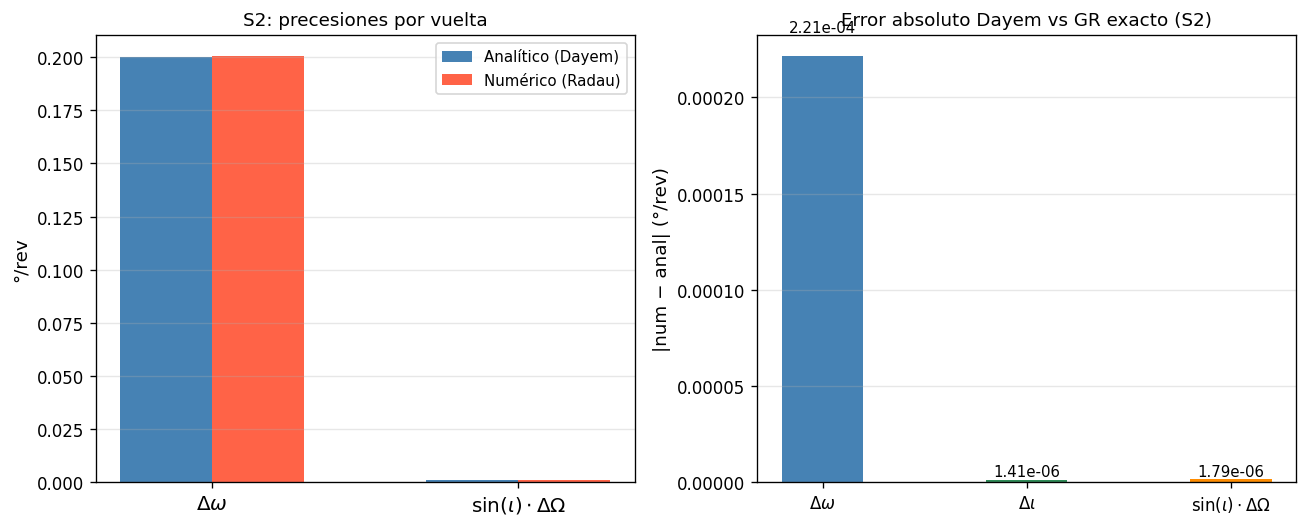

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- Izquierda: Δω y sin(ι)·ΔΩ analítico vs numérico ---
ax1 = axes[0]
quantities = [r"$\Delta\omega$", r"$\sin(\iota)\cdot\Delta\Omega$"]
anal = [om_a, sin_a]
num  = [om_n, sin_n]
x = [0, 1]
w = 0.3
ax1.bar([xi - w/2 for xi in x], anal, w, label="Analítico (Dayem)", color="steelblue")
ax1.bar([xi + w/2 for xi in x], num,  w, label="Numérico (Radau)",  color="tomato")
ax1.set_xticks(x)
ax1.set_xticklabels(quantities, fontsize=12)
ax1.set_ylabel("°/rev", fontsize=11)
ax1.set_title("S2: precesiones por vuelta", fontsize=11)
ax1.legend(fontsize=9); ax1.grid(axis="y", alpha=0.3)

# --- Derecha: error absoluto ---
ax2 = axes[1]
err_labels = [r"$\Delta\omega$", r"$\Delta\iota$", r"$\sin(\iota)\cdot\Delta\Omega$"]
err_vals   = [abs(om_n - om_a), abs(in_n - in_a), abs(sin_n - sin_a)]
colors     = ["steelblue", "seagreen", "darkorange"]
bars = ax2.bar(err_labels, err_vals, color=colors, width=0.4)
ax2.set_ylabel("|num − anal| (°/rev)", fontsize=11)
ax2.set_title("Error absoluto Dayem vs GR exacto (S2)", fontsize=11)
for bar, v in zip(bars, err_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, v * 1.05,
             f"{v:.2e}", ha="center", va="bottom", fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/s2_dayem_vs_fujita.jpg")
plt.show()

In [26]:
# Barrido en spin χ — S2 (inc = 134.567°, elementos orbitales fijos)
def measure_numeric(ics, a_spin, N_pts=50000):
    from scipy.signal import find_peaks as _fp
    kerr_loc = Kerr(mass=1, a=a_spin)
    P_loc = ics._get_period()
    t_loc = np.linspace(0, 1.2 * P_loc, N_pts)
    path_loc = kerr_loc.geodesic.get_path(ics, t_loc,integrator="Radau2", adaptative=False)
    xs_c = path_loc.convert_to("Cartesian").xs
    r_loc = np.sqrt(xs_c[1]**2 + xs_c[2]**2 + xs_c[3]**2)
    idx, _ = _fp(-r_loc, distance=N_pts // 4)
    if r_loc[0] < r_loc[1] and (len(idx) == 0 or idx[0] > 50):
        idx = np.concatenate([[0], idx])
    assert len(idx) >= 2, f"Faltan pericentros: {len(idx)}"
    i0, i1 = idx[0], idx[1]
    om = np.unwrap(np.deg2rad(path_loc.omega))
    ic = np.unwrap(np.deg2rad(path_loc.inc))
    Om = np.unwrap(np.deg2rad(path_loc.Omega))
    return (
        np.rad2deg(om[i1] - om[i0]),
        np.rad2deg(ic[i1] - ic[i0]),
        np.rad2deg(np.sin(ic[i0]) * (Om[i1] - Om[i0])),
    )

a_values = [0.1, 0.3, 0.5, 0.7, 0.9]
rows_spin = []
for a_val in a_values:
    d_s = Dayem2025(ics_s2, a=a_val)
    om_a_s  = np.rad2deg(d_s.get_Delta_omega())
    in_a_s  = np.rad2deg(d_s.get_Delta_i())
    sin_a_s = np.rad2deg(d_s.get_Delta_sin_i_Delta_Omega())
    om_n_s, in_n_s, sin_n_s = measure_numeric(ics_s2, a_val)
    rows_spin.append([
        a_val,
        om_a_s, om_n_s, om_n_s - om_a_s,
        in_a_s, in_n_s, in_n_s - in_a_s,
        sin_a_s, sin_n_s, sin_n_s - sin_a_s,
    ])

cols_spin = pd.MultiIndex.from_tuples([
    ("", "chi"),
    ("Δω", "analitico"), ("Δω", "numerico"), ("Δω", "error"),
    ("Δι", "analitico"), ("Δι", "numerico"), ("Δι", "error"),
    ("sin(ι)·ΔΩ", "analitico"),
    ("sin(ι)·ΔΩ", "numerico"),
    ("sin(ι)·ΔΩ", "error"),
])
df_spin = pd.DataFrame(rows_spin, columns=cols_spin).set_index(("", "chi"))
df_spin.index.name = "χ"
print(df_spin)

           Δω                                Δι                              \
    analitico  numerico     error     analitico      numerico         error   
χ                                                                             
0.1  0.197115  0.197337  0.000221  7.733013e-21  1.568088e-07  1.568088e-07   
0.3  0.197862  0.198206  0.000344  2.323198e-20  4.708863e-07  4.708863e-07   
0.5  0.198610  0.198847  0.000237  3.877487e-20  7.843970e-07  7.843970e-07   
0.7  0.199359  0.199581  0.000222  5.436169e-20  1.096491e-06  1.096491e-06   
0.9  0.200109  0.200331  0.000221  6.999243e-20  1.405277e-06  1.405277e-06   

    sin(ι)·ΔΩ                          
    analitico  numerico         error  
χ                                      
0.1  0.000126  0.000126  2.026791e-07  
0.3  0.000379  0.000380  6.075108e-07  
0.5  0.000633  0.000634  1.008227e-06  
0.7  0.000888  0.000889  1.403953e-06  
0.9  0.001143  0.001145  1.787856e-06  


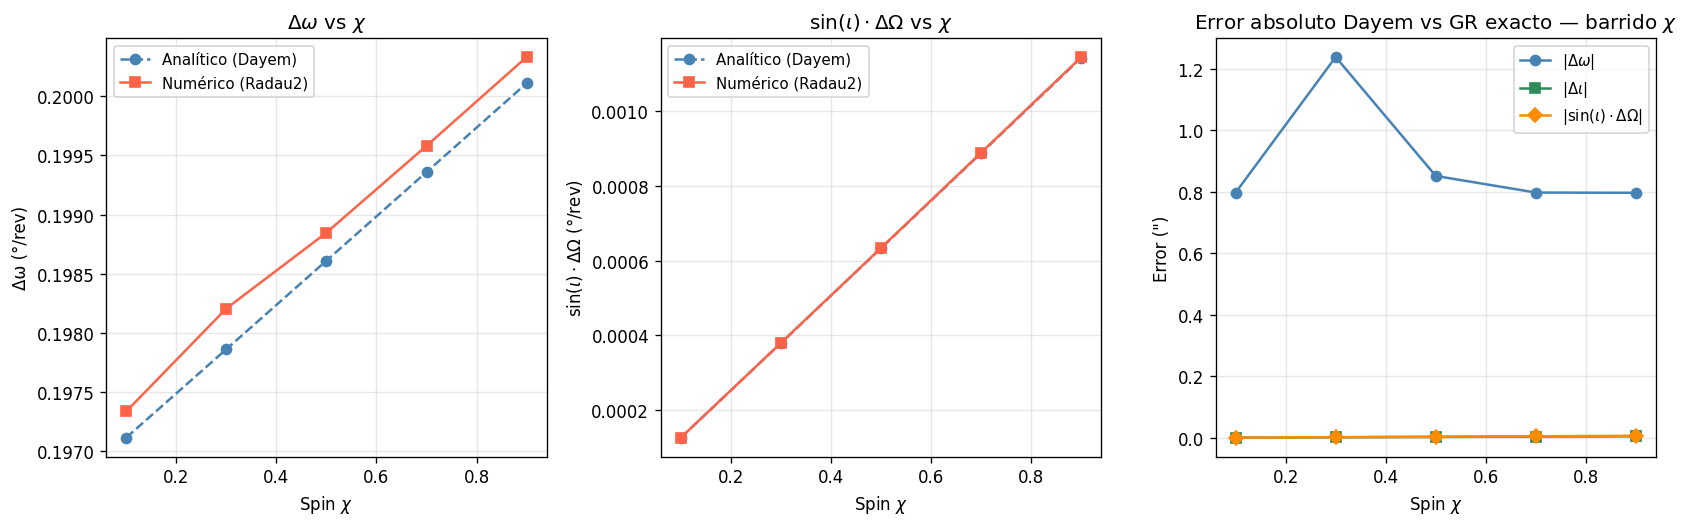

In [27]:
_chi_p    = df_spin.index.values
_err_om_p  = np.abs(df_spin[("Δω",                     "error")].values)
_err_in_p  = np.abs(df_spin[("Δι",                     "error")].values)
_err_sin_p = np.abs(df_spin[("sin(ι)·ΔΩ",  "error")].values)
_om_a_sp   = df_spin[("Δω",                    "analitico")].values
_om_n_sp   = df_spin[("Δω",                    "numerico")].values
_sin_a_sp  = df_spin[("sin(ι)·ΔΩ", "analitico")].values
_sin_n_sp  = df_spin[("sin(ι)·ΔΩ", "numerico")].values

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ax1 = axes[0]
ax1.plot(_chi_p, _om_a_sp,  "o--", color="steelblue", label="Analítico (Dayem)")
ax1.plot(_chi_p, _om_n_sp,  "s-",  color="tomato",    label="Numérico (Radau2)")
ax1.set_xlabel(r"Spin $\chi$"); ax1.set_ylabel("Δω (°/rev)")
ax1.set_title(r"$\Delta\omega$ vs $\chi$")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(_chi_p, _sin_a_sp, "o--", color="steelblue", label="Analítico (Dayem)")
ax2.plot(_chi_p, _sin_n_sp, "s-",  color="tomato",    label="Numérico (Radau2)")
ax2.set_xlabel(r"Spin $\chi$")
ax2.set_ylabel(r"$\sin(\iota)\cdot\Delta\Omega$ (°/rev)")
ax2.set_title(r"$\sin(\iota)\cdot\Delta\Omega$ vs $\chi$")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

ax3 = axes[2]
ax3.plot(_chi_p, _err_om_p  * 3600, "o-", color="steelblue", label=r"$|\Delta\omega|$")
ax3.plot(_chi_p, _err_in_p  * 3600, "s-", color="seagreen",  label=r"$|\Delta\iota|$")
ax3.plot(_chi_p, _err_sin_p * 3600, "D-", color="darkorange",
         label=r"$|\sin(\iota)\cdot\Delta\Omega|$")
ax3.set_xlabel(r"Spin $\chi$"); ax3.set_ylabel('Error (")')
ax3.set_title(r"Error absoluto Dayem vs GR exacto — barrido $\chi$")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/s2_spin_sweep_errors.jpg")
plt.show()

In [28]:
fig_3d = plot.plot()
fig_3d.write_html(f"{FIGURES_DIR}/orbit_s2.html")
fig_3d

In [20]:
P

np.float64(25195186.58398061)

# 3. Barrido en ζ (a = 0.9)

Comparar Δω, Δι, Δ(sin ι·ΔΩ) analítico vs numérico para ζ ∈ {15°, 30°, 45°, 60°, 75°}, con BH spin χ = 0.9 (inc, Ω, ω fijos a valores de S2).

In [21]:
zeta_values = [15.0, 30.0, 45.0, 60.0, 75.0]
a_spin = 0.9

rows = []
for zeta_deg in zeta_values:
    ics_loop = rn.coordinates.ApparentOrbitalElements(
        a     = a_rg,
        e     = 0.884649,
        inc   = ics_s2.inc,
        Omega = ics_s2.Omega,
        omega = ics_s2.omega,
        zeta  = zeta_deg,
        eta   = ics_s2.eta,
        mass  = M_SgrA,
    )
    d_loop = Dayem2025(ics_loop, a=a_spin)
    om_a  = np.rad2deg(d_loop.get_Delta_omega())
    in_a  = np.rad2deg(d_loop.get_Delta_i())
    sin_a = np.rad2deg(d_loop.get_Delta_sin_i_Delta_Omega())
    om_n, in_n, sin_n = measure_numeric(ics_loop, a_spin)
    rows.append([
        zeta_deg,
        om_a, om_n, om_n - om_a,
        in_a, in_n, in_n - in_a,
        sin_a, sin_n, sin_n - sin_a,
    ])

cols = pd.MultiIndex.from_tuples([
    ("",          "zeta"),
    ("Δω",        "analitico"),
    ("Δω",        "numerico"),
    ("Δω",        "error"),
    ("Δι",        "analitico"),
    ("Δι",        "numerico"),
    ("Δι",        "error"),
    ("sin(ι)·ΔΩ", "analitico"),
    ("sin(ι)·ΔΩ", "numerico"),
    ("sin(ι)·ΔΩ", "error"),
])
df_sweep = pd.DataFrame(rows, columns=cols).set_index(("", "zeta"))
df_sweep.index.name = "ζ"
df_sweep.to_csv(f"{FIGURES_DIR}/sweep_zeta_results.csv")
df_sweep

Δω                            Δι                          \
     analitico  numerico     error analitico  numerico         error   
ζ                                                                      
15.0  0.200223  0.200453  0.000230 -0.000277 -0.000276  1.327588e-06   
30.0  0.200098  0.200329  0.000231 -0.000536 -0.000535  1.116842e-06   
45.0  0.199743  0.199964  0.000222 -0.000758 -0.000757  8.032927e-07   
60.0  0.199181  0.199391  0.000210 -0.000928 -0.000927  4.401159e-07   
75.0  0.198453  0.198652  0.000199 -0.001033 -0.001033  7.997024e-08   

     sin(ι)·ΔΩ                          
     analitico  numerico         error  
ζ                                       
15.0  0.000888  0.000889  1.124346e-06  
30.0  0.000571  0.000572  2.918115e-07  
45.0  0.000215  0.000215 -6.091096e-07  
60.0 -0.000155 -0.000157 -1.446388e-06  
75.0 -0.000514 -0.000517 -2.104339e-06

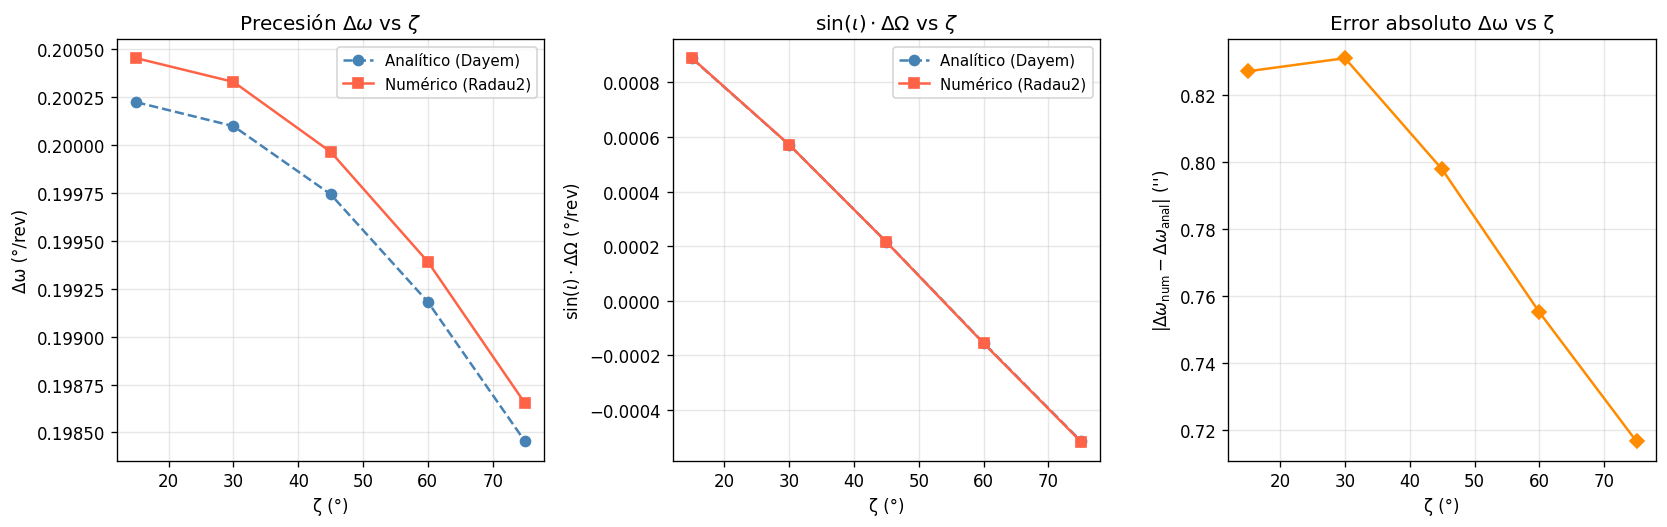

In [24]:
_zeta  = df_sweep.index.values
_om_a  = df_sweep[("Δω",                    "analitico")].values
_om_n  = df_sweep[("Δω",                    "numerico")].values
_sin_a = df_sweep[("sin(ι)·ΔΩ", "analitico")].values
_sin_n = df_sweep[("sin(ι)·ΔΩ", "numerico")].values
_err   = df_sweep[("Δω",                    "error")].values * 3600  # °→''

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ax1 = axes[0]
ax1.plot(_zeta, _om_a, "o--", color="steelblue", label="Analítico (Dayem)")
ax1.plot(_zeta, _om_n, "s-",  color="tomato",    label="Numérico (Radau2)")
ax1.set_xlabel("ζ (°)"); ax1.set_ylabel("Δω (°/rev)")
ax1.set_title(r"Precesión $\Delta\omega$ vs $\zeta$"); ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(_zeta, _sin_a, "o--", color="steelblue", label="Analítico (Dayem)")
ax2.plot(_zeta, _sin_n, "s-",  color="tomato",    label="Numérico (Radau2)")
ax2.set_xlabel("ζ (°)"); ax2.set_ylabel(r"$\sin(\iota)\cdot\Delta\Omega$ (°/rev)")
ax2.set_title(r"$\sin(\iota)\cdot\Delta\Omega$ vs $\zeta$"); ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

ax3 = axes[2]
ax3.plot(_zeta, _err, "D-", color="darkorange")
ax3.set_xlabel("ζ (°)")
ax3.set_ylabel(r"$|\Delta\omega_{\rm num} - \Delta\omega_{\rm anal}|$ ('')")
ax3.set_title("Error absoluto Δω vs ζ")
ax3.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/sweep_zeta_comparison.jpg", dpi=200)
plt.show()